In [21]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [22]:
ROOT = Path("output")

rows = []

for threshold_dir in ROOT.iterdir():

    if not threshold_dir.is_dir():
        continue

    try:
        threshold = float(threshold_dir.name)
    except:
        continue

    score_root = threshold_dir / "output_by_scores"

    if not score_root.exists():
        continue

    for score_dir in score_root.iterdir():

        if not score_dir.is_dir():
            continue

        score = int(score_dir.name)

        results_file = score_dir / "training_stats.csv"
        stats_file = score_dir / "stats.csv"
        test_file = score_dir / "test_metrics.csv"

        if not results_file.exists():
            continue

        results = pd.read_csv(results_file)

        if stats_file.exists():
            stats = pd.read_csv(stats_file)
            execution_time = stats.loc[0, "execution_time_seconds"]
        else:
            execution_time = None

        if test_file.exists():
            test = pd.read_csv(test_file)

            test_accuracy = test.loc[0, "test_accuracy"]
            test_recall = test.loc[0, "test_recall"]
            test_f1 = test.loc[0, "test_f1_score"]

        else:
            test_accuracy = None
            test_recall = None
            test_f1 = None

        for _, row in results.iterrows():

            rows.append({

                "threshold": threshold,
                "score": score,

                "method": row["method"],
                "params": row["params"],

                "train_accuracy": row["accuracy"],
                "train_recall": row["recall"],
                "train_f1": row["f1_score"],

                "test_accuracy": test_accuracy,
                "test_recall": test_recall,
                "test_f1": test_f1,

                "execution_time": execution_time

            })

df = pd.DataFrame(rows)

print(df.head())

   threshold  score    method               params  train_accuracy  \
0       0.09    321  spectral  {'n_clusters': 550}        0.289950   
1       0.09    321  spectral  {'n_clusters': 500}        0.291303   
2       0.09    321  spectral  {'n_clusters': 494}        0.285029   
3       0.09    321  spectral  {'n_clusters': 450}        0.263993   
4       0.09    321  spectral  {'n_clusters': 400}        0.259565   

   train_recall  train_f1  test_accuracy  test_recall   test_f1  \
0      0.289950  0.242800       0.176056     0.176056  0.078925   
1      0.291303  0.239880       0.176056     0.176056  0.078925   
2      0.285029  0.226438       0.176056     0.176056  0.078925   
3      0.263993  0.211103       0.176056     0.176056  0.078925   
4      0.259565  0.202591       0.176056     0.176056  0.078925   

   execution_time  
0      172.873932  
1      172.873932  
2      172.873932  
3      172.873932  
4      172.873932  


In [23]:
analysis_dir = Path("analysis")

analysis_dir.mkdir(exist_ok=True)

df.to_csv(
    analysis_dir / "all_results.csv",
    index=False
)

In [24]:
df_no_mst = pd.read_csv("analysis/all_results no mst.csv")

In [25]:
graph_dir = analysis_dir / "graphs"

graph_dir.mkdir(exist_ok=True)

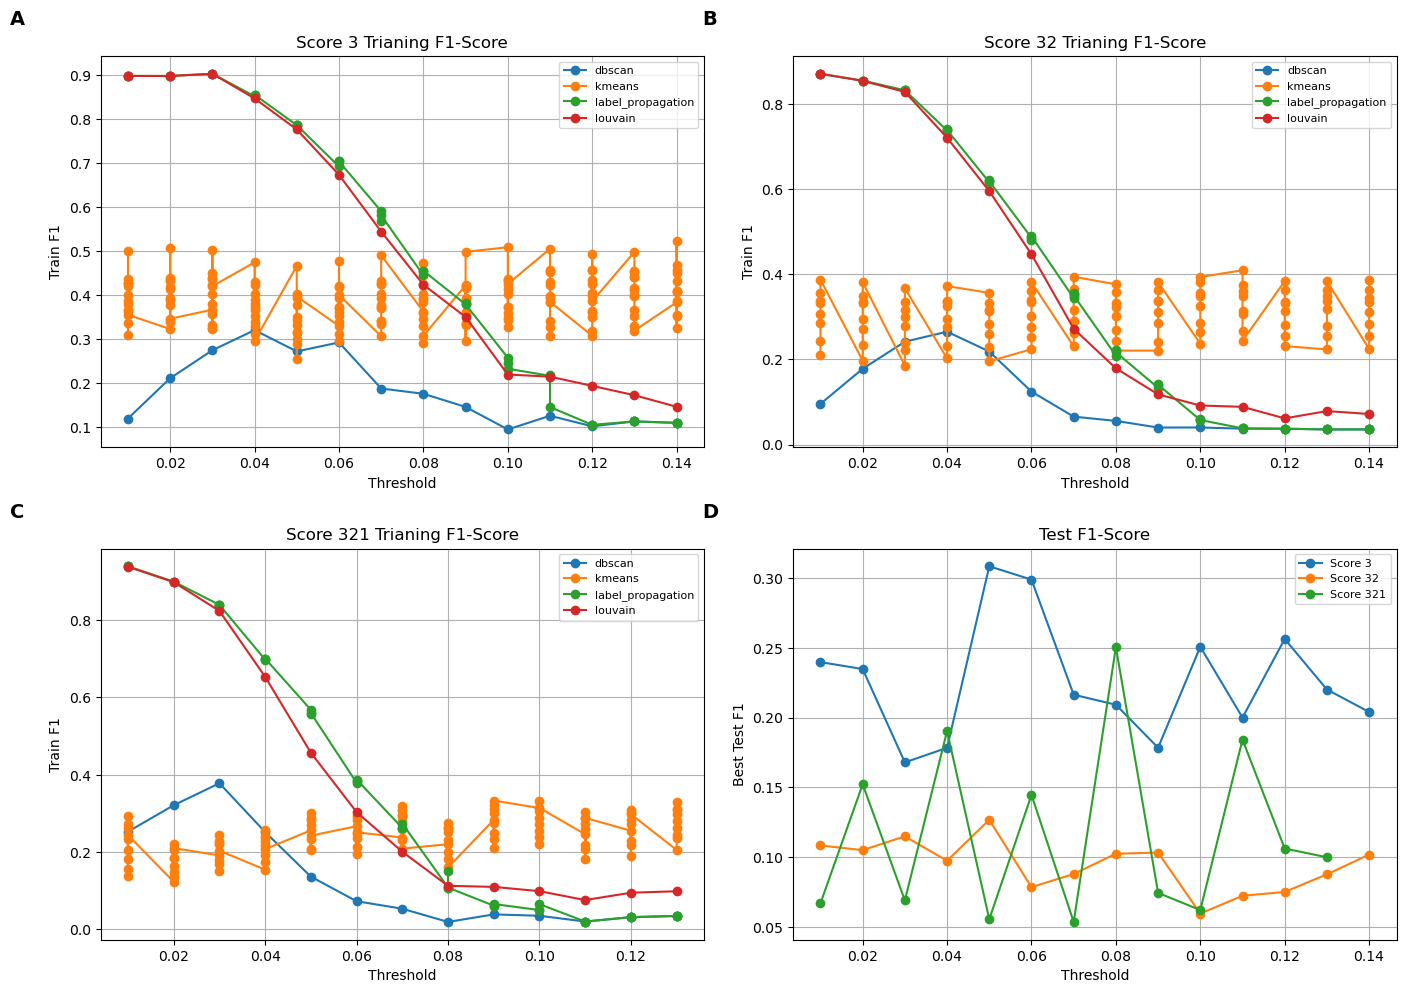

In [26]:
import matplotlib.pyplot as plt

scores = sorted(df_no_mst.score.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

letters = ["A", "B", "C", "D"]

# ---------- Train F1 graphs ----------
for i, score in enumerate(scores):

    ax = axes[i]

    tmp = df_no_mst[df_no_mst.score == score]

    for method in sorted(tmp.method.unique()):

        cur = (
            tmp[tmp.method == method]
            .sort_values("threshold")
        )

        ax.plot(
            cur.threshold,
            cur.train_f1,
            marker="o",
            label=method
        )

    ax.set_title(f"Score {score} Trianing F1-Score")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Train F1")
    ax.grid(True)

    # אות בפינה (A/B/C)
    ax.text(
        -0.15, 1.08,
        letters[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold"
    )

    ax.legend(fontsize=8)

# ---------- Summary graph ----------
ax = axes[3]

for score in scores:

    tmp = df_no_mst[df_no_mst.score == score]

    best = (
        tmp.groupby("threshold")["test_f1"]
        .max()
        .reset_index()
    )

    ax.plot(
        best.threshold,
        best.test_f1,
        marker="o",
        label=f"Score {score}"
    )

ax.set_title("Test F1-Score")
ax.set_xlabel("Threshold")
ax.set_ylabel("Best Test F1")
ax.grid(True)
ax.legend(fontsize=8)

ax.text(
    -0.15, 1.08,
    "D",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    graph_dir / "all_panels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

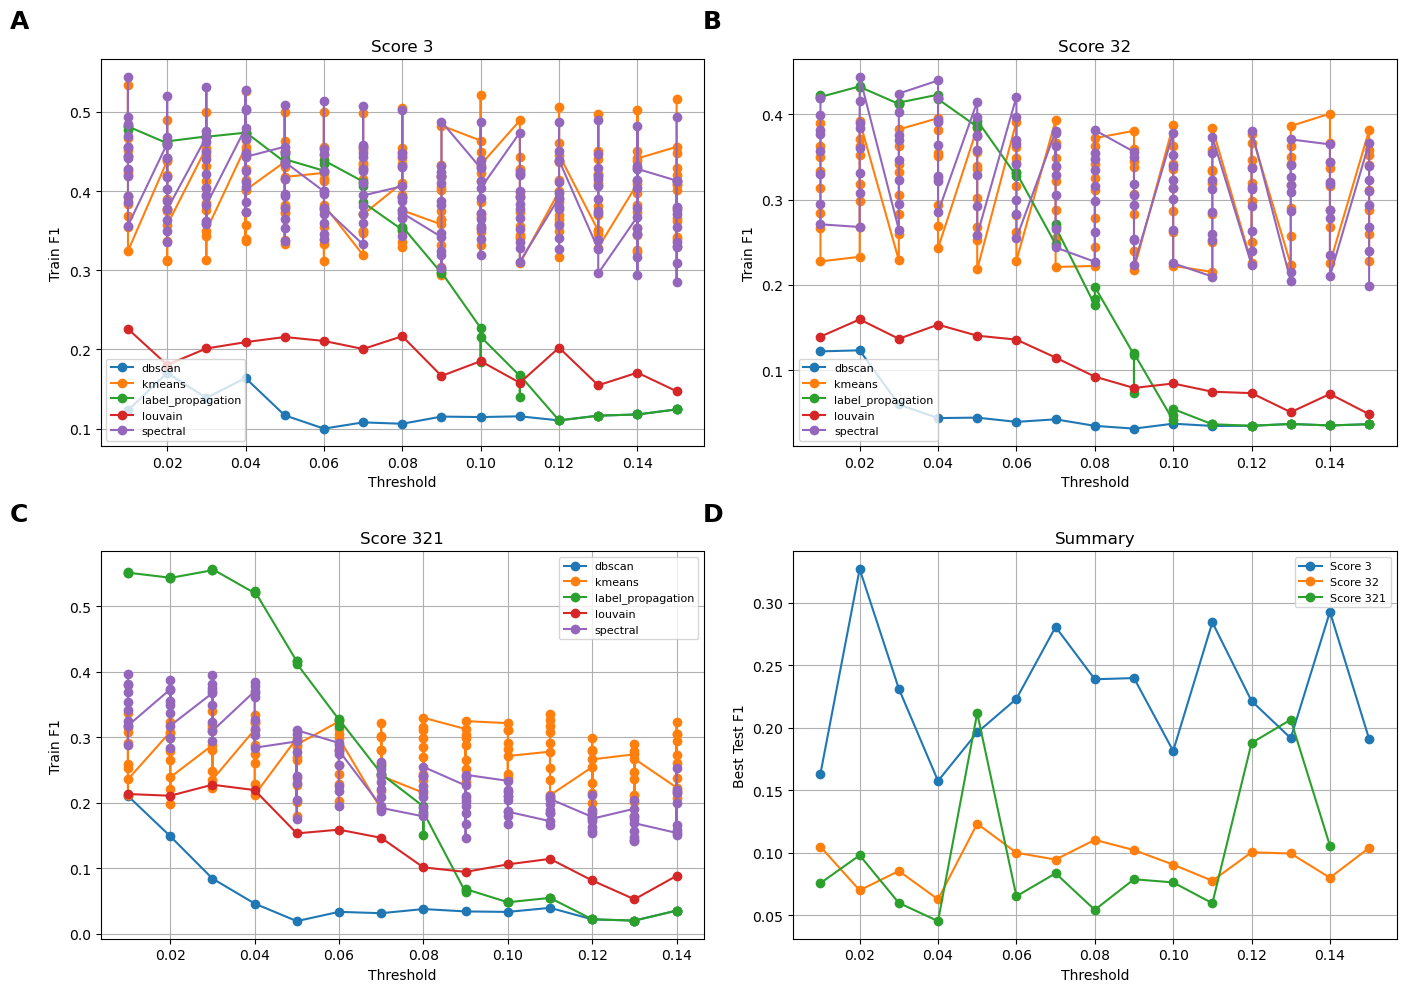

In [27]:
df_mst = pd.read_csv("analysis/all_results.csv")

import matplotlib.pyplot as plt

scores = sorted(df_mst.score.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

letters = ["A", "B", "C", "D"]

# ---------- Train F1 graphs ----------
for i, score in enumerate(scores):

    ax = axes[i]

    tmp = df_mst[df_mst.score == score]

    for method in sorted(tmp.method.unique()):

        cur = (
            tmp[tmp.method == method]
            .sort_values("threshold")
        )

        ax.plot(
            cur.threshold,
            cur.train_f1,
            marker="o",
            label=method
        )

    ax.set_title(f"Score {score}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Train F1")
    ax.grid(True)

    # אות בפינה (A/B/C)
    ax.text(
        -0.15, 1.08,
        letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold"
    )

    ax.legend(fontsize=8)

# ---------- Summary graph ----------
ax = axes[3]

for score in scores:

    tmp = df_mst[df_mst.score == score]

    best = (
        tmp.groupby("threshold")["test_f1"]
        .max()
        .reset_index()
    )

    ax.plot(
        best.threshold,
        best.test_f1,
        marker="o",
        label=f"Score {score}"
    )

ax.set_title("Summary")
ax.set_xlabel("Threshold")
ax.set_ylabel("Best Test F1")
ax.grid(True)
ax.legend(fontsize=8)

ax.text(
    -0.15, 1.08,
    "D",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    graph_dir / "all_panels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

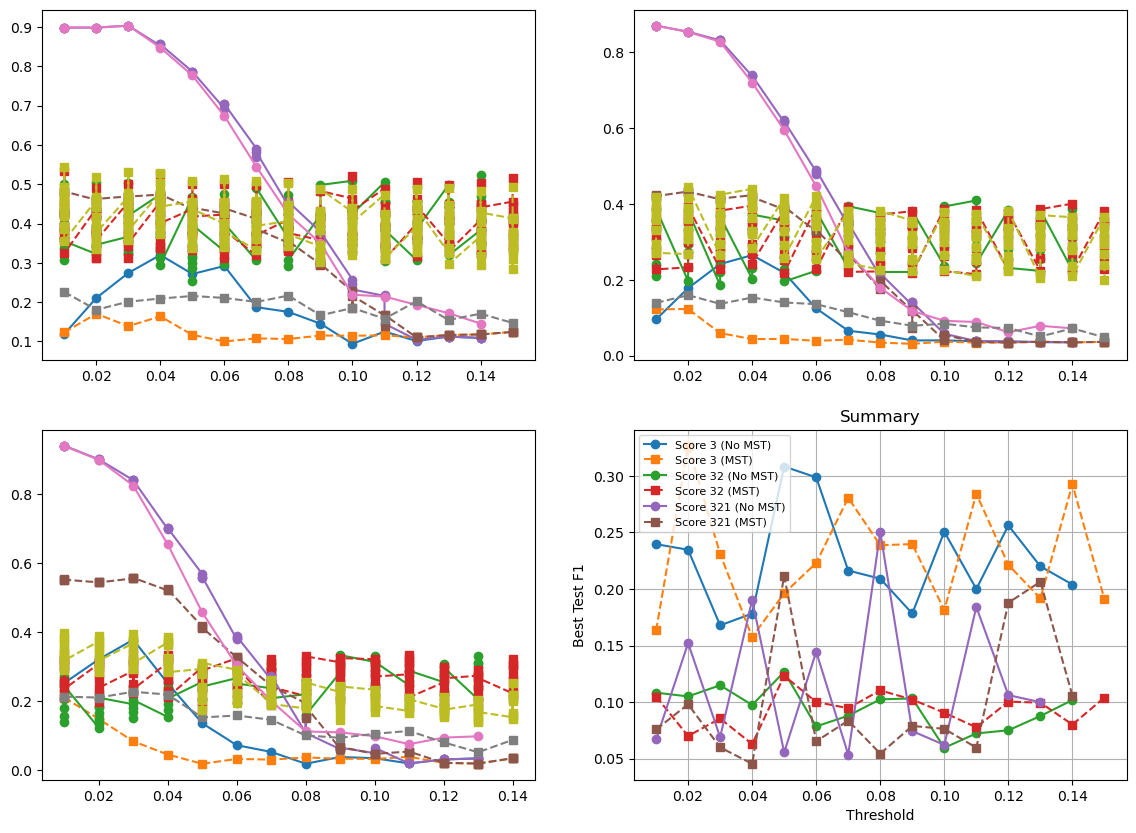

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# טעינת הנתונים
df_no_mst = pd.read_csv("analysis/all_results no mst.csv")
df_mst = pd.read_csv("analysis/all_results.csv")

scores = sorted(df_no_mst.score.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, score in enumerate(scores):

    ax = axes[i]

    methods = sorted(
    set(df_no_mst.method.unique()) |
    set(df_mst.method.unique())
)

    for method in methods:

        # בלי MST
        cur = (
            df_no_mst[
                (df_no_mst.score == score) &
                (df_no_mst.method == method)
            ]
            .sort_values("threshold")
        )
        if not cur.empty:
            ax.plot(
                cur.threshold,
                cur.train_f1,
                '-o',
                label=f"{method} (No MST)"
            )

        # עם MST
        cur = (
            df_mst[
                (df_mst.score == score) &
                (df_mst.method == method)
            ]
            .sort_values("threshold")
        )
        if not cur.empty:
            ax.plot(
                cur.threshold,
                cur.train_f1,
                '--s',
                label=f"{method} (MST)"
            )

ax = axes[3]

for score in scores:

    best = (
        df_no_mst[df_no_mst.score == score]
        .groupby("threshold")["test_f1"]
        .max()
        .reset_index()
    )

    ax.plot(
        best.threshold,
        best.test_f1,
        "-o",
        label=f"Score {score} (No MST)"
    )

    best = (
        df_mst[df_mst.score == score]
        .groupby("threshold")["test_f1"]
        .max()
        .reset_index()
    )

    ax.plot(
        best.threshold,
        best.test_f1,
        "--s",
        label=f"Score {score} (MST)"
    )

ax.set_title("Summary")
ax.set_xlabel("Threshold")
ax.set_ylabel("Best Test F1")
ax.grid(True)
ax.legend(fontsize=8)


#     ax.set_title(f"Score {score}")
#     ax.set_xlabel("Threshold")
#     ax.set_ylabel("Train F1")
#     ax.grid(True)
#     ax.legend(fontsize=7)

# plt.tight_layout()
# plt.show()

In [29]:
df_no_mst = pd.read_csv("analysis/all_results no mst.csv")
df_mst = pd.read_csv("analysis/all_results.csv")
df_no_mst["mst"] = "No MST"

df_mst["mst"] = "MST"

df = pd.concat([df_no_mst, df_mst], ignore_index=True)

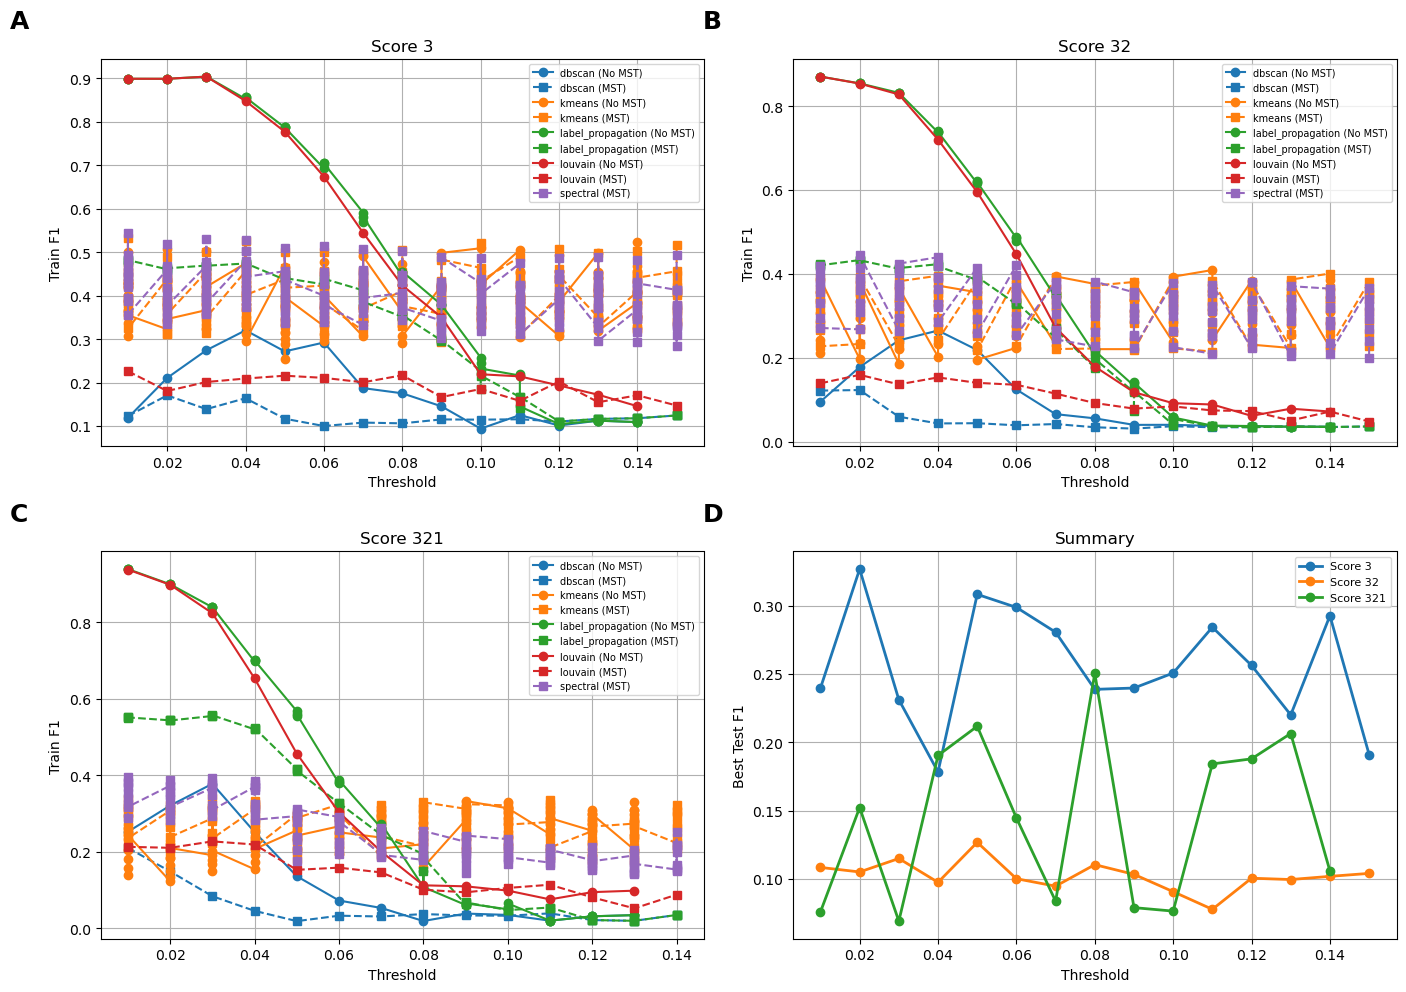

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

scores = sorted(df.score.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

letters = ["A", "B", "C", "D"]

colors = plt.cm.tab10.colors

methods = sorted(df.method.unique())

# ---------- Train F1 ----------
for i, score in enumerate(scores):

    ax = axes[i]

    for j, method in enumerate(methods):

        color = colors[j % len(colors)]

        for mst, ls, marker in [
            ("No MST", "-", "o"),
            ("MST", "--", "s"),
        ]:

            cur = (
                df[
                    (df.score == score)
                    & (df.method == method)
                    & (df.mst == mst)
                ]
                .sort_values("threshold")
            )

            if cur.empty:
                continue

            ax.plot(
                cur.threshold,
                cur.train_f1,
                color=color,
                linestyle=ls,
                marker=marker,
                label=f"{method} ({mst})",
            )

    ax.set_title(f"Score {score}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Train F1")
    ax.grid(True)

    ax.text(
        -0.15,
        1.08,
        letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
    )

    ax.legend(fontsize=7)

# ---------- Summary ----------
ax = axes[3]

for score in scores:

    best = (
        df[df.score == score]
        .groupby("threshold")["test_f1"]
        .max()
        .reset_index()
    )

    ax.plot(
        best.threshold,
        best.test_f1,
        marker="o",
        linewidth=2,
        label=f"Score {score}",
    )

ax.set_title("Summary")
ax.set_xlabel("Threshold")
ax.set_ylabel("Best Test F1")
ax.grid(True)
ax.legend(fontsize=8)

ax.text(
    -0.15,
    1.08,
    "D",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

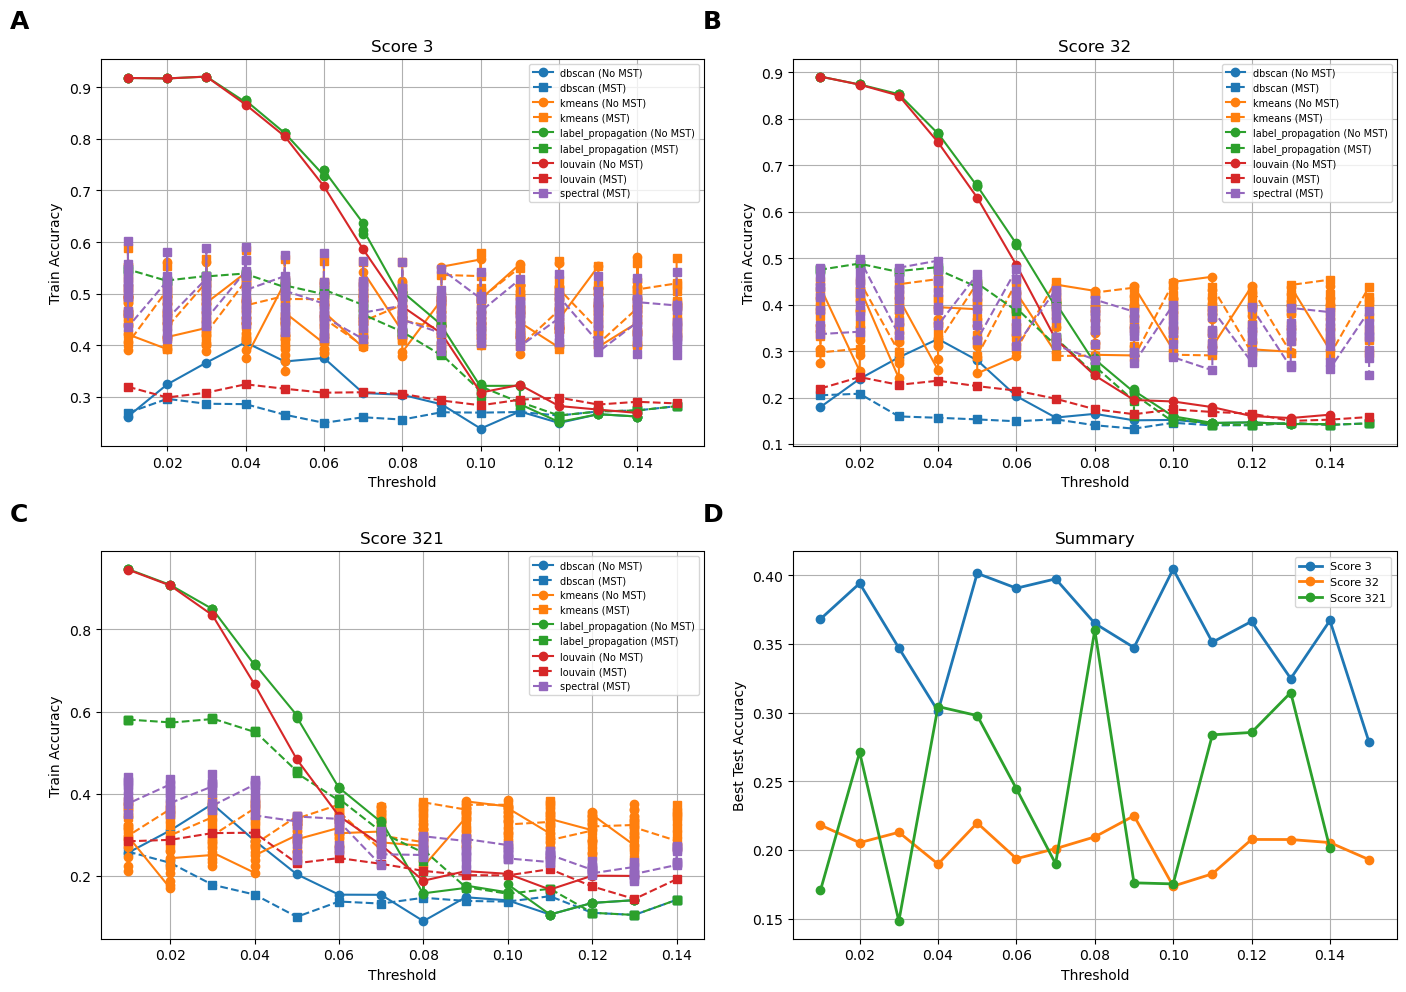

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

scores = sorted(df.score.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

letters = ["A", "B", "C", "D"]

colors = plt.cm.tab10.colors

methods = sorted(df.method.unique())

# ---------- Train F1 ----------
for i, score in enumerate(scores):

    ax = axes[i]

    for j, method in enumerate(methods):

        color = colors[j % len(colors)]

        for mst, ls, marker in [
            ("No MST", "-", "o"),
            ("MST", "--", "s"),
        ]:

            cur = (
                df[
                    (df.score == score)
                    & (df.method == method)
                    & (df.mst == mst)
                ]
                .sort_values("threshold")
            )

            if cur.empty:
                continue

            ax.plot(
                cur.threshold,
                cur.train_accuracy,
                color=color,
                linestyle=ls,
                marker=marker,
                label=f"{method} ({mst})",
            )

    ax.set_title(f"Score {score}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Train Accuracy")
    ax.grid(True)

    ax.text(
        -0.15,
        1.08,
        letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
    )

    ax.legend(fontsize=7)

# ---------- Summary ----------
ax = axes[3]

for score in scores:

    best = (
        df[df.score == score]
        .groupby("threshold")["test_accuracy"]
        .max()
        .reset_index()
    )

    ax.plot(
        best.threshold,
        best.test_accuracy,
        marker="o",
        linewidth=2,
        label=f"Score {score}",
    )

ax.set_title("Summary")
ax.set_xlabel("Threshold")
ax.set_ylabel("Best Test Accuracy")
ax.grid(True)
ax.legend(fontsize=8)

ax.text(
    -0.15,
    1.08,
    "D",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="bold",
)

plt.tight_layout()
plt.show()